## ИТ-компания "Лоция"
### Данные из открытых источников:
| Показатель         | 2023        | 2024        | 2025         |
| ------------------ | ----------- | ----------- | ------------ |
| Выручка            | 1,57 млрд ₽ | 2,30 млрд ₽ | 2,94 млрд ₽  |
| Чистая прибыль     | 202,8 млн ₽ | 186,0 млн ₽ | 136,6 млн ₽  |
| Баланс (активы)    | ~117 млн ₽  | ~994 млн ₽  | ~1,25 млрд ₽ |
| Темп роста выручки | +50,3%      | +46,6%      | +27,5%       |


[Смотреть визуализацию](#Visual)

In [12]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

In [4]:
# 1. Словарь с исходными данными (в виде строк, как в таблице)
data_dict = {
    "Показатель": [
        "Выручка",
        "Чистая прибыль",
        "Баланс (активы)",
        "Темп роста выручки"
    ],
    "2023": [
        "1,57 млрд ₽",
        "202,8 млн ₽",
        "~117 млн ₽",
        "+50,3%"
    ],
    "2024": [
        "2,30 млрд ₽",
        "186,0 млн ₽",
        "~994 млн ₽",
        "+46,6%"
    ],
    "2025": [
        "2,94 млрд ₽",
        "136,6 млн ₽",
        "~1,25 млрд ₽",
        "+27,5%"
    ]
}

In [5]:
# 2. DataFrame из словаря
df = pd.DataFrame(data_dict)
df

,Показатель,2023,2024,2025
0,Выручка,"1,57 млрд ₽","2,30 млрд ₽","2,94 млрд ₽"
1,Чистая прибыль,"202,8 млн ₽","186,0 млн ₽","136,6 млн ₽"
2,Баланс (активы),~117 млн ₽,~994 млн ₽,"~1,25 млрд ₽"
3,Темп роста выручки,"+50,3%","+46,6%","+27,5%"


In [7]:
# ------------------------------------------------------------------
# Вспомогательная функция для конвертации строк в числа (в рублях)
# ------------------------------------------------------------------
def parse_value(val: str) -> float:
    val = val.strip().replace("₽", "").replace("+", "").replace("-", "")
    
    # Убираем тильду
    if "~" in val:
        val = val.replace("~", "")
    
    multiplier = 1.0
    if "млрд" in val:
        multiplier = 1_000_000_000
        val = val.replace("млрд", "")
    elif "млн" in val:
        multiplier = 1_000_000
        val = val.replace("млн", "")
    
    # Заменяем запятую на точку для float
    val = val.replace(",", ".")
    return float(val) * multiplier

def parse_percent(val: str) -> float:
    val = val.strip().replace("%", "").replace("+", "")
    return float(val.replace(",", "."))

# 3. Создаём новый DataFrame с числами (для расчётов и графиков)
df_numeric = df.copy()
for col in ["2023", "2024", "2025"]:
    # Для темпов роста используем отдельный парсер
    if col == "2023" and df_numeric.loc[3, col] == "+50,3%":
        pass  # просто помечаем, что это проценты
    
    for i in range(len(df_numeric)):
        row_name = df_numeric.loc[i, "Показатель"]
        raw = df_numeric.loc[i, col]
        
        if "Темп роста" in row_name:
            df_numeric.loc[i, col] = parse_percent(raw)
        else:
            df_numeric.loc[i, col] = parse_value(raw)

# Переименуем столбцы в int для удобства
df_numeric = df_numeric.rename(columns={"2023": 2023, "2024": 2024, "2025": 2025})

# 4. Для визуализации удобнее длинный формат (melt)
df_melt = df_numeric.melt(
    id_vars=["Показатель"],
    value_vars=[2023, 2024, 2025],
    var_name="Год",
    value_name="Значение"
)

# Разделим метрики на две группы: абсолютные (руб) и относительные (%)
absolute_metrics = ["Выручка", "Чистая прибыль", "Баланс (активы)"]
percent_metrics = ["Темп роста выручки"]

df_melt

,Показатель,Год,Значение
0,Выручка,2023,1570000000.0
1,Чистая прибыль,2023,202800000.0
2,Баланс (активы),2023,117000000.0
3,Темп роста выручки,2023,50.3
4,Выручка,2024,2300000000.0
5,Чистая прибыль,2024,186000000.0
6,Баланс (активы),2024,994000000.0
7,Темп роста выручки,2024,46.6
8,Выручка,2025,2940000000.0
9,Чистая прибыль,2025,136600000.0


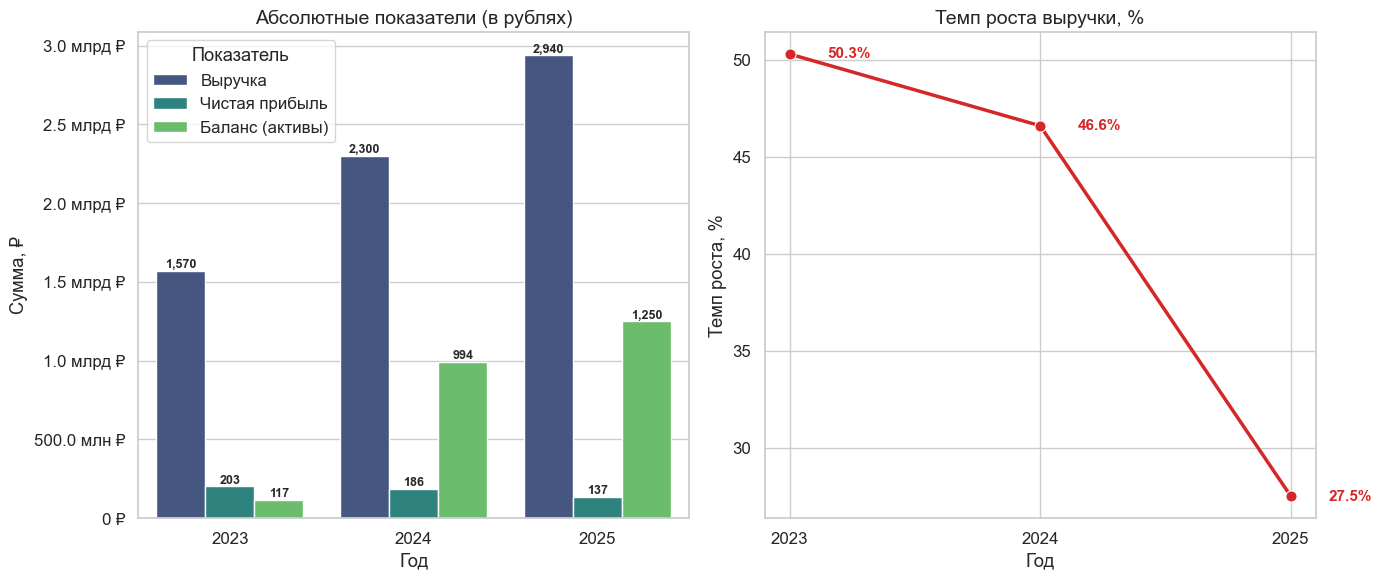

In [28]:
# ------------------------------------------------------------------
# 5. Визуализация
# ------------------------------------------------------------------
sns.set(style="whitegrid", font_scale=1.1)
fig, axs = plt.subplots(1, 2, figsize=(14, 6))

# График 1: абсолютные показатели (столбцы) + подписи: округление до млн и поворот 45°
bar_data = df_melt[df_melt["Показатель"].isin(absolute_metrics)]
bar = sns.barplot(
    data=bar_data,
    x="Год",
    y="Значение",
    hue="Показатель",
    ax=axs[0],
    palette="viridis"
)
axs[0].set_title("Абсолютные показатели (в рублях)", fontsize=14)
axs[0].set_ylabel("Сумма, ₽")

# Форматирование оси Y (читаемо)
def format_ru(x, pos):
    if x >= 1_000_000_000:
        return f"{x/1e9:.1f} млрд ₽"
    elif x >= 1_000_000:
        return f"{x/1e6:.1f} млн ₽"
    else:
        return f"{int(x)} ₽"
axs[0].yaxis.set_major_formatter(FuncFormatter(format_ru))

# Подписи над столбцами: округлено до миллионов, угол 45 градусов
for container in bar.containers:
    for patch in container:
        height = patch.get_height()
        # Округляем до миллионов и показываем как целое число (например, 1570 вместо 1570000000)
        val_in_mln = round(height / 1_000_000)
        axs[0].text(
            patch.get_x() + patch.get_width() / 2,
            height,
            f"{val_in_mln:,}",          # с разделителями тысяч (1 570)
            ha='center',
            va='bottom',
            fontsize=9,
            fontweight='bold',     
            rotation_mode='anchor'
        )

# График 2: темп роста выручки (линия) + подписи смещены вправо
line_data = df_melt[df_melt["Показатель"].isin(percent_metrics)]
line = sns.lineplot(
    data=line_data,
    x="Год",
    y="Значение",
    marker="o",
    linewidth=2.5,
    markersize=8,
    ax=axs[1],
    color="#d62728"
)
axs[1].set_title("Темп роста выручки, %", fontsize=14)
axs[1].set_ylabel("Темп роста, %")
axs[1].set_xticks([2023, 2024, 2025])

# Подписи смещены вправо от вершин
x_shift = 0.15
for x, y in zip(line_data["Год"], line_data["Значение"]):
    axs[1].text(
        x + x_shift,
        y,
        f"{y:.1f}%",
        ha='left',
        va='center',
        fontsize=11,
        fontweight='bold',
        color="#d62728"
    )

plt.tight_layout()
plt.savefig('plot.jpg', dpi=300, bbox_inches='tight')
plt.show()

# Visual